In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [2]:
df = pd.read_csv("../dataset.csv").reset_index(drop=True)

df.head(100)
df.sample(9)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
780,781,51,Male,VA Long Beach,asymptomatic,NaN,218.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0
659,660,56,Male,Switzerland,asymptomatic,140.0,0.0,NaN,normal,121.0,True,1.8,upsloping,NaN,NaN,1
187,188,66,Male,Cleveland,atypical angina,160.0,246.0,False,normal,120.0,True,0.0,flat,3.0,fixed defect,2
481,482,59,Female,Hungary,atypical angina,130.0,188.0,False,normal,124.0,False,1.0,flat,NaN,NaN,0
68,69,59,Male,Cleveland,asymptomatic,170.0,326.0,False,lv hypertrophy,140.0,True,3.4,downsloping,0.0,reversable defect,2
881,882,67,Male,VA Long Beach,asymptomatic,NaN,369.0,False,normal,NaN,NaN,NaN,NaN,NaN,NaN,3
295,296,41,Male,Cleveland,atypical angina,120.0,157.0,False,normal,182.0,False,0.0,upsloping,0.0,normal,0
192,193,43,Male,Cleveland,asymptomatic,132.0,247.0,True,lv hypertrophy,143.0,True,0.1,flat,NaN,reversable defect,1
795,796,75,Male,VA Long Beach,asymptomatic,170.0,203.0,True,st-t abnormality,108.0,False,0.0,NaN,NaN,reversable defect,1


In [3]:
df = df.rename(columns={col: col.lower() for col in df.columns})
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
df.shape

(920, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [6]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [7]:
df.describe(include="str")

,sex,dataset,cp,restecg,slope,thal
count,920,920,920,918,611,434
unique,2,4,4,3,3,3
top,Male,Cleveland,asymptomatic,normal,flat,normal
freq,726,304,496,551,345,196


In [8]:
missing_values = df.isna().sum()
display(missing_values)
print(f"{missing_values/len(df)*100}")

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

id           0.000000
age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
trestbps     6.413043
chol         3.260870
fbs          9.782609
restecg      0.217391
thalch       5.978261
exang        5.978261
oldpeak      6.739130
slope       33.586957
ca          66.413043
thal        52.826087
num          0.000000
dtype: float64


##### Filling missing values in numerical columns with median as it is less affected by outliers compared to mean in terms of medical data.

In [9]:
num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

##### Filling missing values in categorical columns with mode.

In [10]:
cat_cols = ['fbs', 'restecg', 'exang']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

##### Checking percentage of missing values in columns with high missingness to decide on imputation strategy.

In [11]:
total_rows = len(df)

for col in ['slope', 'ca', 'thal']:
    missing_pct = df[col].isna().sum() / total_rows * 100
    print(f"{col}: {missing_pct:.2f}% missing")

slope: 33.59% missing
ca: 66.41% missing
thal: 52.83% missing


##### Dropping 'slope','ca' and 'thal' columns due to high missingness which can lead to biased imputation and affect model performance.

In [12]:
df = df.drop(columns=['slope', 'ca', 'thal'])

In [13]:
missing_values = df.isna().sum()
display(missing_values)
print(f"{missing_values/len(df)*100}")

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
num         0
dtype: int64

id          0.0
age         0.0
sex         0.0
dataset     0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalch      0.0
exang       0.0
oldpeak     0.0
num         0.0
dtype: float64


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  920 non-null    float64
 6   chol      920 non-null    float64
 7   fbs       920 non-null    object 
 8   restecg   920 non-null    str    
 9   thalch    920 non-null    float64
 10  exang     920 non-null    object 
 11  oldpeak   920 non-null    float64
 12  num       920 non-null    int64  
dtypes: float64(4), int64(3), object(2), str(4)
memory usage: 93.6+ KB


In [15]:
df['num'].value_counts()
df['num'].value_counts(normalize=True) * 100

num
0    44.673913
1    28.804348
2    11.847826
3    11.630435
4     3.043478
Name: proportion, dtype: float64

The target variable 'num' is imbalanced with a higher percentage of non-disease cases (0) compared to disease cases (1-4). So, we can consider it as a binary classification problem by converting all non-zero values to 1 (indicating presence of heart disease) and zero values to 0 (indicating absence of heart disease). This will help in simplifying the model and improving performance given the imbalance in the original target variable.

In [16]:
df['num'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

In [17]:
df['num'].value_counts()
df['num'].value_counts(normalize=True) * 100

num
1    55.326087
0    44.673913
Name: proportion, dtype: float64

In [18]:
df['sex'] = df['sex'].astype('category')
df['cp'] = df['cp'].astype('category')
df['restecg'] = df['restecg'].astype('category')
df['dataset'] = df['dataset'].astype('category')
df['exang'] = df['exang'].astype('category')
df['fbs'] = df['fbs'].astype('category')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   id        920 non-null    int64   
 1   age       920 non-null    int64   
 2   sex       920 non-null    category
 3   dataset   920 non-null    category
 4   cp        920 non-null    category
 5   trestbps  920 non-null    float64 
 6   chol      920 non-null    float64 
 7   fbs       920 non-null    category
 8   restecg   920 non-null    category
 9   thalch    920 non-null    float64 
 10  exang     920 non-null    category
 11  oldpeak   920 non-null    float64 
 12  num       920 non-null    int64   
dtypes: category(6), float64(4), int64(3)
memory usage: 55.9 KB


In [19]:
df.to_csv("dataset_processed.csv", index=False)

#### Numerical Feature Analysis

##### Distribution plots

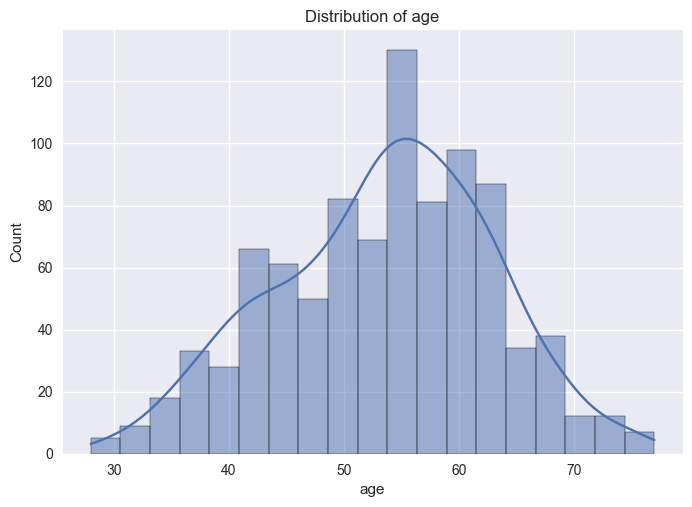

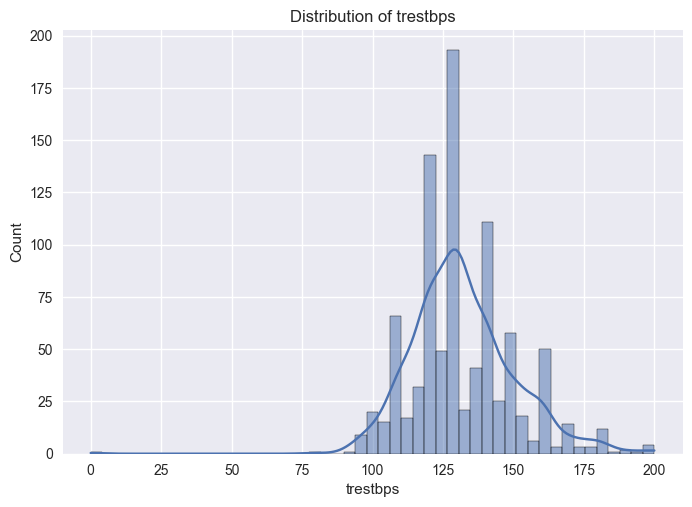

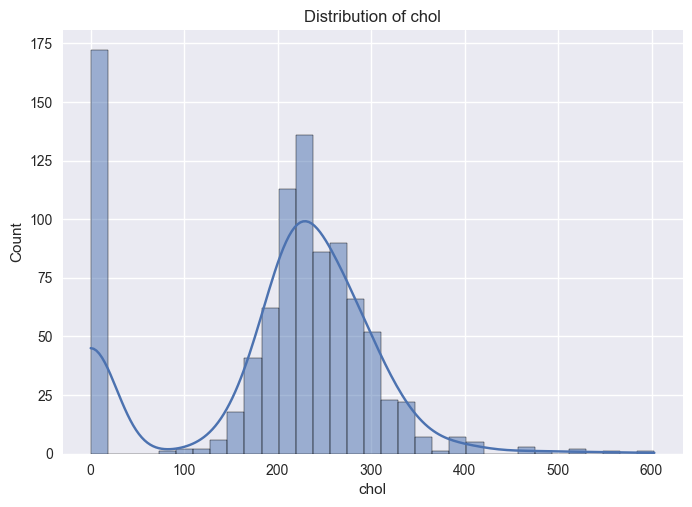

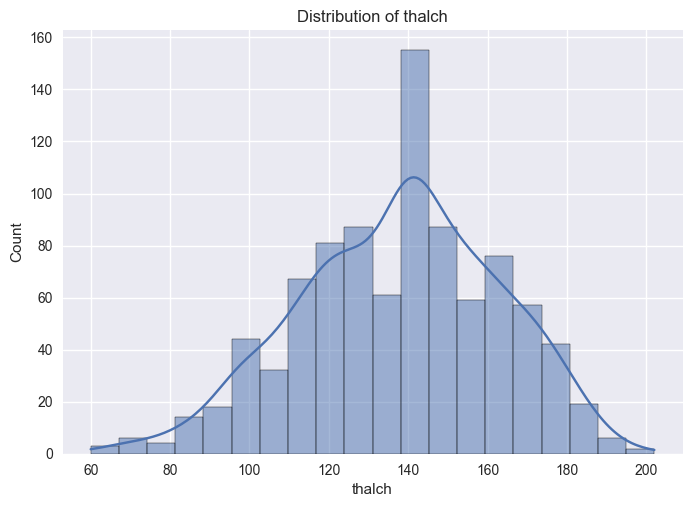

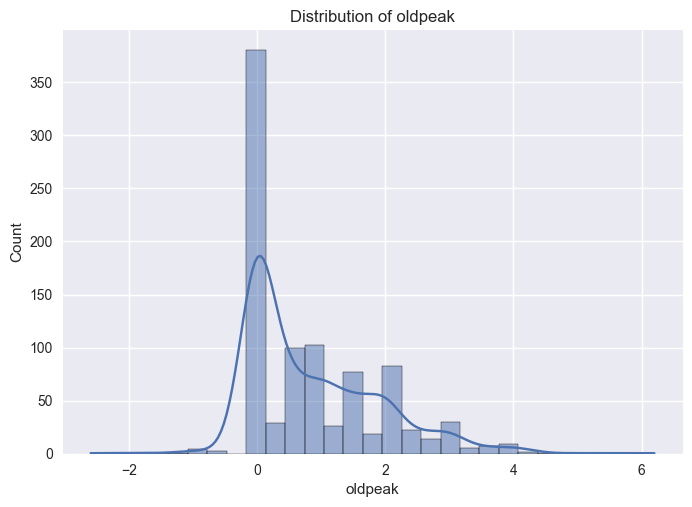

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['age','trestbps','chol','thalch','oldpeak']

for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

##### Boxplots for numerical columns to check for outliers

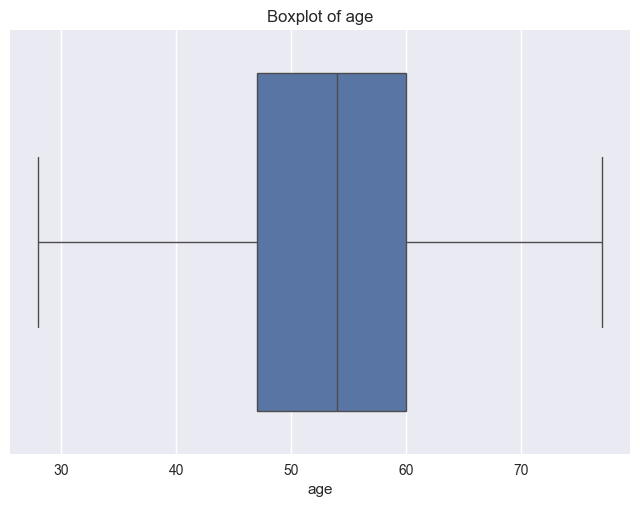

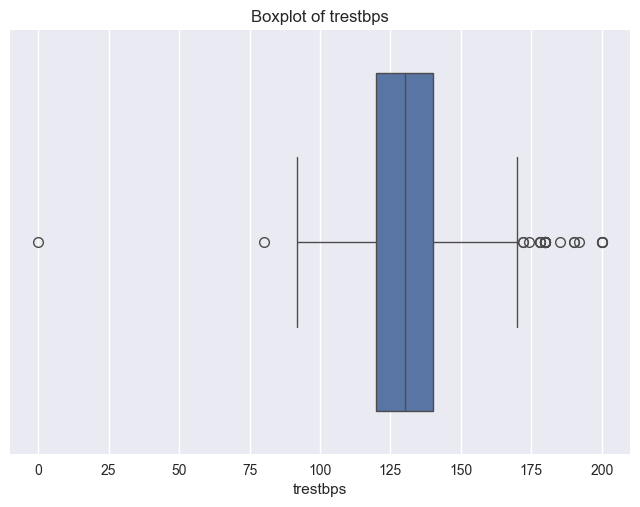

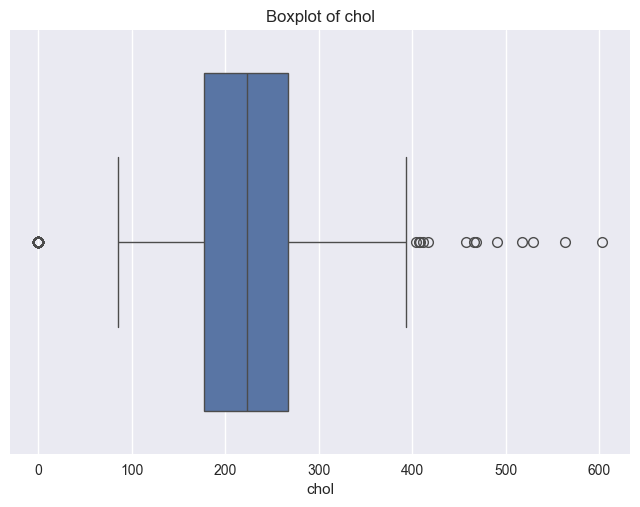

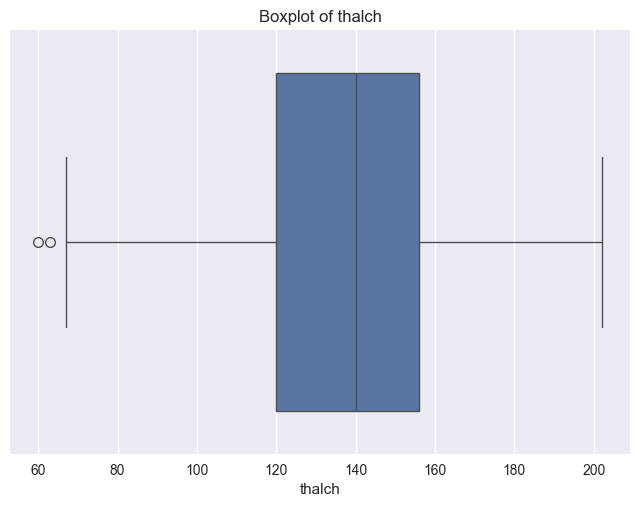

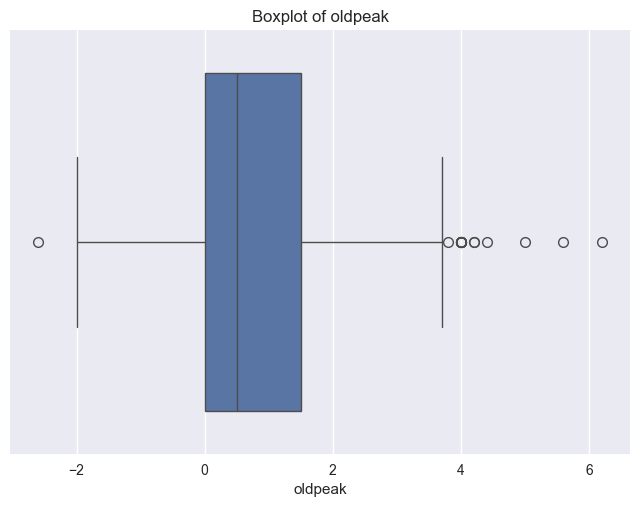

In [21]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### Categorical Feature Analysis

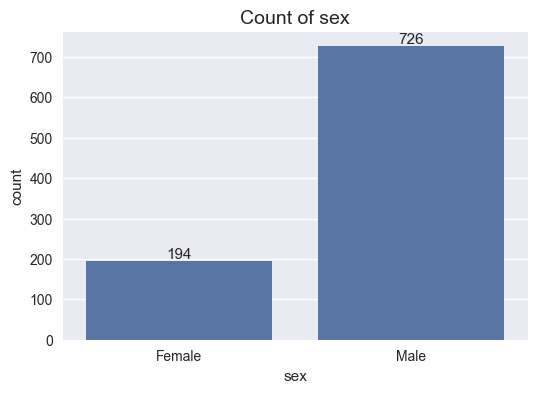

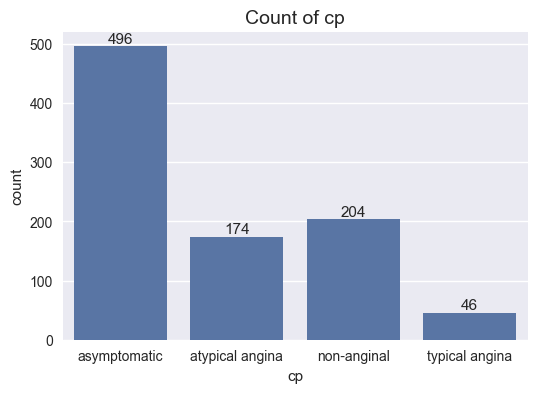

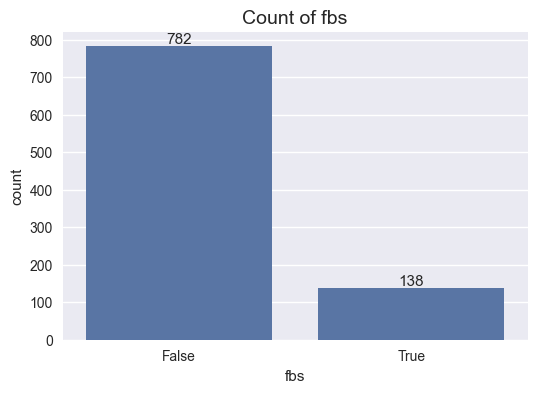

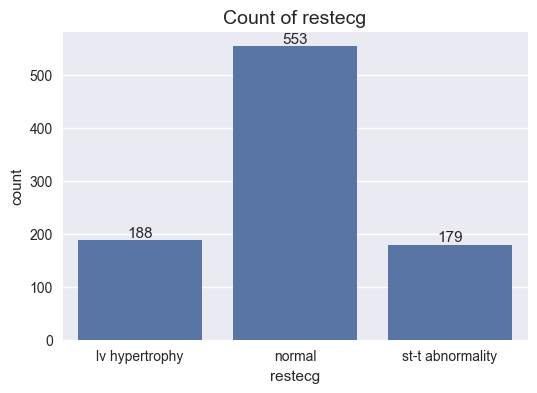

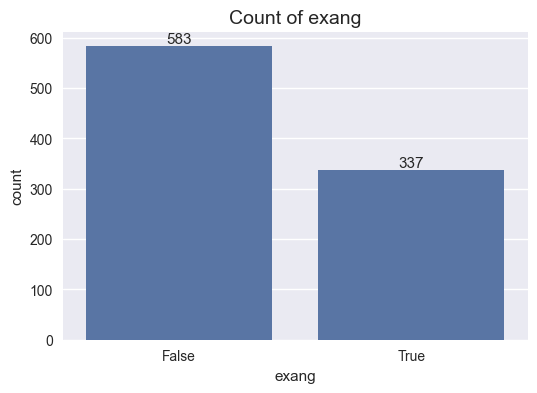

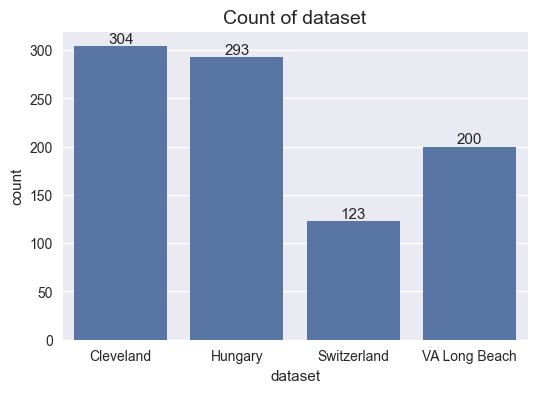

In [22]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'dataset']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    ax = sns.countplot(x=col, data=df)
    plt.title(f'Count of {col}', fontsize=14)
    
    # Annotate counts on top of bars
    for p in ax.patches:
        count = int(p.get_height())
        ax.annotate(count, 
                    (p.get_x() + p.get_width() / 2., count), 
                    ha='center', va='bottom', fontsize=11)
    
    plt.show()

### Check Relationships in Data

##### Numerical vs Numerical (Correlation)

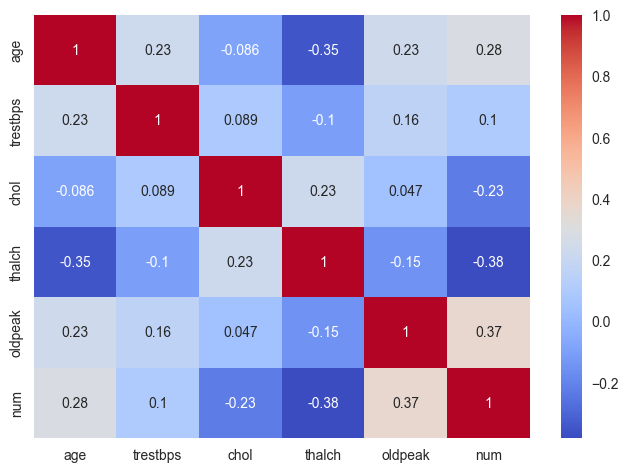

In [23]:
corr = df[num_cols + ['num']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

##### Numerical vs Target

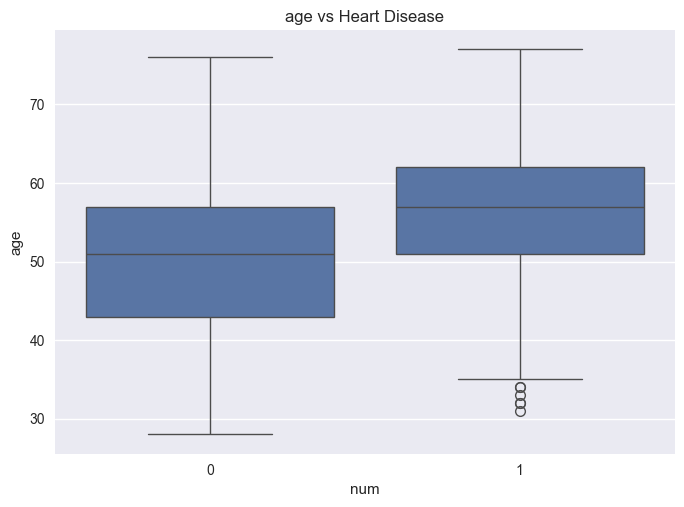

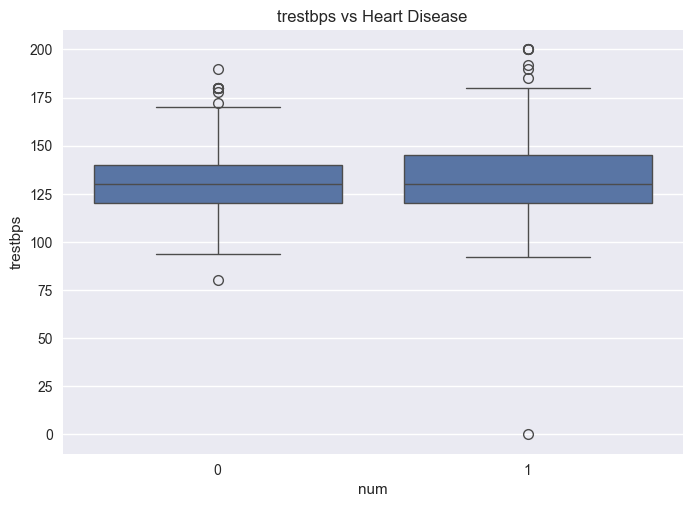

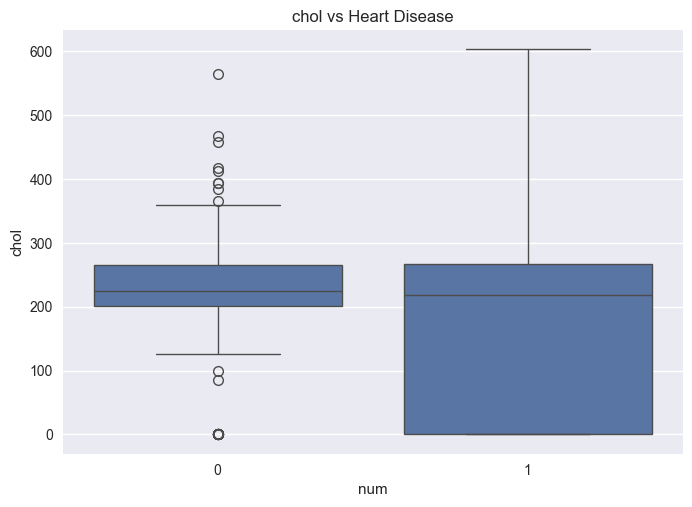

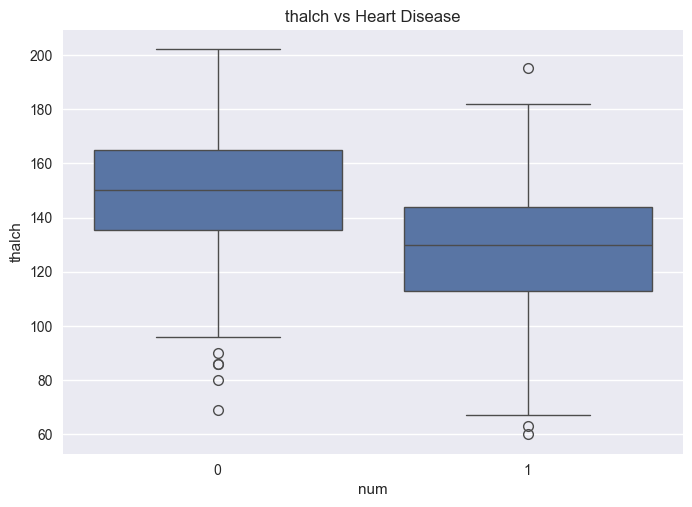

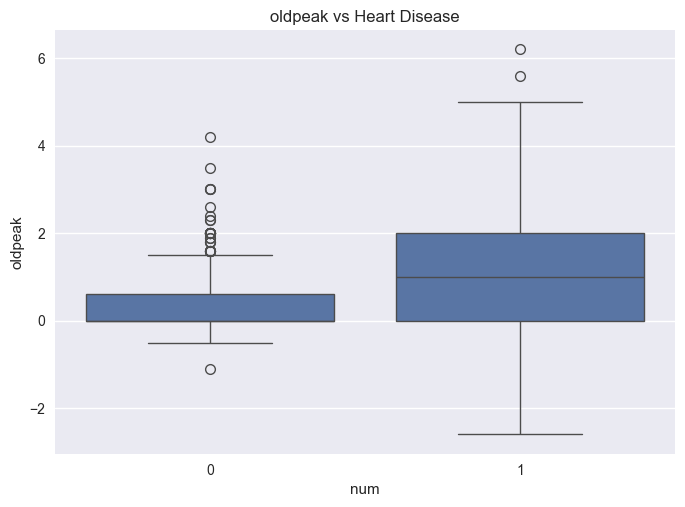

In [24]:
for col in num_cols:
    sns.boxplot(x='num', y=col, data=df)
    plt.title(f'{col} vs Heart Disease')
    plt.show()

In [25]:
pd.crosstab(df['dataset'], df['num'], normalize='index')

num,0,1
dataset,,
Cleveland,0.542763,0.457237
Hungary,0.638225,0.361775
Switzerland,0.065041,0.934959
VA Long Beach,0.255000,0.745000
